# Part 5 - Exercise 3
# POS tagging με απλό stacked CNN

Στην άσκηση αυτή επαναλαμβάνεται το ίδιο POS tagging task που είχε χρησιμοποιηθεί και στα προηγούμενα parts, αλλά τώρα το μοντέλο αλλάζει σε CNN.

Η συνέχεια των ασκήσεων είναι η εξής:

- **Part 3 Exercise 5:** window based MLP POS tagger.
- **Part 4 Exercise 2:** BiLSTM / RNN POS tagger.
- **Part 5 Exercise 3:** CNN POS tagger.

Η βασική ιδέα είναι ότι το μεγαλύτερο μέρος του pipeline παραμένει ίδιο με το Part 4, ώστε η σύγκριση να γίνεται. Δηλαδή κρατάμε ίδιο dataset, ίδιο vocabulary κλπ κλπ.

Η κύρια αλλαγή βρίσκεται στο model section: στο Part 4 χρησιμοποιήθηκε BiLSTM, ενώ εδώ χρησιμοποιείται stacked CNN με n gram filters και residual connections.


## 1. Basic setup

Το section αυτό είναι ίδιο με το Part 4.


In [1]:
import os
import random
import urllib.request
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Τρέχει σε:", device)


Τρέχει σε: cpu


## 2. Ανάγνωση του UD English EWT dataset

Σε αυτό το section διαβάζεται το ίδιο Universal Dependencies English EWT dataset που χρησιμοποιήθηκε και στο Part 4.


In [2]:
data_folder = "ud_english_ewt"
os.makedirs(data_folder, exist_ok=True)

base_url = "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master"

split_files = {
    "train": "en_ewt-ud-train.conllu",
    "dev": "en_ewt-ud-dev.conllu",
    "test": "en_ewt-ud-test.conllu",
}

for split, filename in split_files.items():
    local_path = os.path.join(data_folder, filename)

    if not os.path.exists(local_path):
        print(f"Γίνεται λήψη του {split} αρχείου")
        urllib.request.urlretrieve(f"{base_url}/{filename}", local_path)
    else:
        print(f"Χρήση υπάρχοντος {split} αρχείου")


def load_conllu_words_and_tags(path):
    sentences = []
    sentence = []

    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()

            # Κενή γραμμή σημαίνει ότι τελείωσε η πρόταση.
            if line == "":
                if sentence:
                    sentences.append(sentence)
                    sentence = []
                continue

            # Οι γραμμές που αρχίζουν με # είναι σχόλια στα conllu αρχεία.
            if line.startswith("#"):
                continue

            parts = line.split("	")
            token_number = parts[0]

            # Αγνοούμε multi-word tokens και empty nodes.
            if "-" in token_number or "." in token_number:
                continue

            word = parts[1].lower()
            tag = parts[3]
            sentence.append((word, tag))

    if sentence:
        sentences.append(sentence)

    return sentences


sent_by_split = {
    split: load_conllu_words_and_tags(os.path.join(data_folder, filename))
    for split, filename in split_files.items()
}

train_sentences = sent_by_split["train"]
dev_sentences = sent_by_split["dev"]
test_sentences = sent_by_split["test"]

for split, sents in sent_by_split.items():
    print(f"{split}: {len(sents)} sentences")


Γίνεται λήψη του train αρχείου
Γίνεται λήψη του dev αρχείου
Γίνεται λήψη του test αρχείου
train: 12544 sentences
dev: 2001 sentences
test: 2077 sentences


## 3. Έλεγχος dataset και προηγούμενα αποτελέσματα για comparison

Σε αυτό το section γίνεται πρώτα ένας βασικός έλεγχος του dataset και μετά προστίθενται τα αποτελέσματα των προηγούμενων εργασιών.

Πρώτα υπολογίζονται:

- αριθμός sentences σε train/dev/test,
- αριθμός tokens,
- μέσο μήκος πρότασης.


Μετά δημιουργούνται δύο μικροί πίνακες με προηγούμενα αποτελέσματα (δεν τα ξανατρέχω φυσικά):

1. **Window MLP Part 3** από το Part 3 Exercise 5,
2. **BiLSTM RNN Part 4** από το Part 4 Exercise 2.


Το final comparison στο τέλος θα έχει:

- most frequent tag baseline,
- Part 3 window MLP,
- Part 4 BiLSTM RNN,
- Part 5 stacked CNN.


In [3]:
def number_of_tokens(sentences):
    return sum(len(sentence) for sentence in sentences)


# Βασική περίληψη του dataset.
# Χρησιμοποιείται για να δούμε το μέγεθος των train/dev/test splits.
summary_rows = []
for split, sents in sent_by_split.items():
    tokens = number_of_tokens(sents)
    summary_rows.append({
        "split": split,
        "sentences": len(sents),
        "tokens": tokens,
        "avg_sentence_length": tokens / len(sents)
    })

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)


# Προηγούμενη μέθοδος από Part 3 Exercise 5.
# Αυτό είναι το window based MLP POS tagger.
old_window_mlp = pd.DataFrame([
    ["Window MLP Part 3", "train", 0.9663, 0.9118, 0.9260, 0.9608],
    ["Window MLP Part 3", "dev",   0.8945, 0.8336, 0.8486, 0.8880],
    ["Window MLP Part 3", "test",  0.8689, 0.8463, 0.8563, 0.8983],
], columns=["model", "split", "macro_precision", "macro_recall", "macro_f1", "macro_pr_auc"])


# Προηγούμενη μέθοδος από Part 4 Exercise 2.
# Αυτό είναι το BiLSTM/RNN POS tagger.
old_bilstm_rnn = pd.DataFrame([
    ["BiLSTM RNN Part 4", "train", 0.9349, 0.8767, 0.9002, 0.9396],
    ["BiLSTM RNN Part 4", "dev",   0.8576, 0.7966, 0.8190, 0.8574],
    ["BiLSTM RNN Part 4", "test",  0.8562, 0.8071, 0.8278, 0.8709],
], columns=["model", "split", "macro_precision", "macro_recall", "macro_f1", "macro_pr_auc"])

print("Προηγούμενα αποτελέσματα για comparison:")
display(pd.concat([old_window_mlp, old_bilstm_rnn], ignore_index=True))


,split,sentences,tokens,avg_sentence_length
0,train,12544,204578,16.308833
1,dev,2001,25148,12.567716
2,test,2077,25094,12.081849


Προηγούμενα αποτελέσματα για comparison:


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,Window MLP Part 3,train,0.9663,0.9118,0.9260,0.9608
1,Window MLP Part 3,dev,0.8945,0.8336,0.8486,0.8880
2,Window MLP Part 3,test,0.8689,0.8463,0.8563,0.8983
3,BiLSTM RNN Part 4,train,0.9349,0.8767,0.9002,0.9396
4,BiLSTM RNN Part 4,dev,0.8576,0.7966,0.8190,0.8574
5,BiLSTM RNN Part 4,test,0.8562,0.8071,0.8278,0.8709


## 4. Vocabulary και mini-batches

Το section αυτό το κράτησα ίδιο με το Part 4. Είναι μόνο η προετοιμασία των δεδομένων: vocabulary, tags, padding κλπ.


In [4]:
PAD_WORD = "<PAD>"
UNK_WORD = "<UNK>"
PAD_TAG = "<PAD_TAG>"

min_word_freq = 2

word_counts = Counter()
real_tags = set()

for sent in train_sentences:
    for word, tag in sent:
        word_counts[word] += 1
        real_tags.add(tag)

words_kept = sorted([w for w, c in word_counts.items() if c >= min_word_freq])
tag_list = [PAD_TAG] + sorted(real_tags)
vocab = [PAD_WORD, UNK_WORD] + words_kept

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

tag2idx = {t: i for i, t in enumerate(tag_list)}
idx2tag = {i: t for t, i in tag2idx.items()}

pad_word_id = word2idx[PAD_WORD]
unk_word_id = word2idx[UNK_WORD]
pad_tag_id = tag2idx[PAD_TAG]

print("Μέγεθος vocabulary:", len(word2idx))
print("Πραγματικά POS tags:", len(tag_list) - 1)
print("Tags:", ", ".join(tag_list[1:]))


def encode_sentence(sentence):
    word_ids = [word2idx.get(word, unk_word_id) for word, tag in sentence]
    tag_ids = [tag2idx[tag] for word, tag in sentence]
    return word_ids, tag_ids


class PosSentenceDataset(Dataset):
    def __init__(self, sentences):
        self.encoded = [encode_sentence(sentence) for sentence in sentences]

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, idx):
        return self.encoded[idx]


def make_batch(batch):
    word_lists, tag_lists = zip(*batch)
    lengths = torch.tensor([len(x) for x in word_lists], dtype=torch.long)

    max_len = int(lengths.max())
    batch_size = len(batch)

    x = torch.full((batch_size, max_len), pad_word_id, dtype=torch.long)
    y = torch.full((batch_size, max_len), pad_tag_id, dtype=torch.long)

    for i, (words, tags) in enumerate(zip(word_lists, tag_lists)):
        x[i, :len(words)] = torch.tensor(words, dtype=torch.long)
        y[i, :len(tags)] = torch.tensor(tags, dtype=torch.long)

    return x, y, lengths


batch_size = 32

loaders = {
    "train": DataLoader(PosSentenceDataset(train_sentences), batch_size=batch_size, shuffle=True, collate_fn=make_batch),
    "dev": DataLoader(PosSentenceDataset(dev_sentences), batch_size=batch_size, shuffle=False, collate_fn=make_batch),
    "test": DataLoader(PosSentenceDataset(test_sentences), batch_size=batch_size, shuffle=False, collate_fn=make_batch),
}

sample_x, sample_y, sample_len = next(iter(loaders["train"]))
print("Παράδειγμα batch words:", tuple(sample_x.shape))
print("Παράδειγμα batch tags: ", tuple(sample_y.shape))
print("Πρώτα lengths:", sample_len[:5].tolist())


Μέγεθος vocabulary: 8867
Πραγματικά POS tags: 17
Tags: ADJ, ADP, ADV, AUX, CCONJ, DET, INTJ, NOUN, NUM, PART, PRON, PROPN, PUNCT, SCONJ, SYM, VERB, X
Παράδειγμα batch words: (32, 54)
Παράδειγμα batch tags:  (32, 54)
Πρώτα lengths: [21, 26, 18, 16, 10]


## 5. Stacked CNN POS tagger

Αυτό είναι το βασικό section που αλλάζει σε σχέση με το Part 4.

Στο Part 4 η βασική μορφή του model ήταν:

`Embeddings σε BiLSTM σε output layer`

Στο Part 5 γίνεται:

`Embeddings σε stacked CNN blocks σε output layer`

Το input παραμένει ίδιο:

`batch_size x sentence_length`

Το output παραμένει επίσης ίδιο:

`batch_size x sentence_length x number_of_tags`

Άρα το υπόλοιπο training και evaluation code μπορεί να μείνει σχεδόν ίδιο.

### Τι κάνει το CNN

Το CNN κοιτάει μικρά τοπικά κομμάτια της πρότασης. Για αυτό χρησιμοποιούνται n-gram filters:

- filter size `2`: κοιτάει ζευγάρια γειτονικών θέσεων,
- filter size `3`: κοιτάει τριάδες γειτονικών θέσεων,
- filter size `4`: κοιτάει τετράδες γειτονικών θέσεων.

Έτσι το model μπορεί να μάθει local patterns γύρω από κάθε word position.

### Γιατί χρειάζεται same length output

Στο POS tagging πρέπει να προβλεφθεί ένα POS tag για κάθε word. Άρα μετά από κάθε convolution πρέπει να κρατηθεί το ίδιο sentence length.

Για αυτό υπάρχει η βοηθητική συνάρτηση `keep_same_length`.

### Γιατί υπάρχει residual connection

Σε κάθε CNN block προστίθεται η παλιά αναπαράσταση μαζί με τη νέα CNN πληροφορία:

`old representation + new CNN information`

Αυτό βοηθά το model να κρατά την προηγούμενη πληροφορία και να προσθέτει μόνο κάτι επιπλέον από τα CNN filters.

### Γιατί δεν χρησιμοποιείται global max pooling

Στο text classification μπορεί να χρησιμοποιηθεί global max pooling, γιατί θέλουμε μία πρόβλεψη για όλο το κείμενο.

Εδώ όμως έχουμε POS tagging, άρα θέλουμε μία πρόβλεψη για κάθε θέση της πρότασης. Για αυτό κρατάμε representation για κάθε word position και στο τέλος εφαρμόζεται dense layer σε κάθε θέση.


In [5]:
def keep_same_length(conv_output, wanted_length):
    """
    Conv1d
    Αυτή η βοηθητική συνάρτηση κρατά το CNN output στο ίδιο μήκος με την πρόταση.
    """
    current_length = conv_output.size(-1)

    if current_length > wanted_length:
        return conv_output[:, :, :wanted_length]

    if current_length < wanted_length:
        missing = wanted_length - current_length
        return F.pad(conv_output, (0, missing))

    return conv_output


class SimpleCnnBlock(nn.Module):
    """
    Ένα μικρό CNN block για POS tagging.

    Input shape:
        batch_size x sentence_length x channels

    Output shape:
        batch_size x sentence_length x channels

    Κρατάμε το ίδιο μήκος, γιατί χρειαζόμαστε μία πρόβλεψη για κάθε word.
    """
    def __init__(self, channels, filter_sizes=(2, 3, 4), dropout=0.25):
        super().__init__()

        # Ένα convolutionν για κάθε n gram size.
        # Για παράδειγμα, k=3 σημαίνεει ότι το filter κοιτάει 3 γειτονικές θέσεις.
        self.filters = nn.ModuleList([
            nn.Conv1d(
                in_channels=channels,
                out_channels=channels,
                kernel_size=k,
                padding=k // 2
            )
            for k in filter_sizes
        ])

        # Αφού εφαρμοστούν πολλά filters, τα ενώνουμε και τα φέρνουμε πίσω
        # στο αρχικό channel size.
        self.combine_filters = nn.Linear(channels * len(filter_sizes), channels)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        sentence_length = x.size(1)

        # Η PyTorch Conv1d περιμένει: batch x channels x length.
        # Το δικό μας x είναι: batch x length x channels.
        x_for_cnn = x.transpose(1, 2)

        all_filter_outputs = []

        for conv in self.filters:
            out = conv(x_for_cnn)
            out = keep_same_length(out, sentence_length)
            out = torch.relu(out)

            # Το ξαναφέρνουμε στη μορφή: batch x length x channels.
            all_filter_outputs.append(out.transpose(1, 2))

        # Ενώνουμε τα outputs από τα 2-gram, 3-gram και 4-gram filters.
        joined = torch.cat(all_filter_outputs, dim=-1)

        # Φέρνουμε το ενωμένο vector πίσω στο κανονικό channel size.
        new_info = self.combine_filters(joined)
        new_info = self.dropout(new_info)

        # Residual connection: κρατάμε την παλιά πληροφορία και προσθέτουμε τη νέα CNN πληροφορία.
        return self.norm(x + new_info)


class SimpleCnnPosTagger(nn.Module):
    """
    Το POS tagger του Part 5.
    Αυτό αντικαθιστά το BiLSTM model του Part 4.
    Το υπόλοιπο pipeline μπορεί να μείνει σχεδόν ίδιο.
    """
    def __init__(self, vocab_size, num_tags, emb_dim=80, channels=128,
                 num_blocks=2, filter_sizes=(2, 3, 4), dropout=0.25):
        super().__init__()

        # Word id σε word embedding.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_word_id
        )

        # Μετατροπή από embedding dimension στο channel dimension του CNN.
        self.input_projection = nn.Linear(emb_dim, channels)

        # Stacked CNN blocks.
        # num_blocks=2 σημαίνει ότι μπαίνουν δύο CNN blocks στη σειρά.
        self.blocks = nn.ModuleList([
            SimpleCnnBlock(channels=channels, filter_sizes=filter_sizes, dropout=dropout)
            for _ in range(num_blocks)
        ])

        # Το ίδιο dense layer εφαρμόζεται σε κάθε word position.
        # Παράγει ένα score για κάθε πιθανό POS tag.
        self.output_layer = nn.Linear(channels, num_tags)

    def forward(self, word_batch, lengths=None):
        # word_batch shape: batch x sentence_length
        emb = self.embedding(word_batch)

        # x shape: batch x sentence_length x channels
        x = torch.relu(self.input_projection(emb))

        # Εφαρμόζουμε τα stacked CNN blocks.
        for block in self.blocks:
            x = block(x)

        # logits shape: batch x sentence_length x num_tags
        logits = self.output_layer(x)
        return logits


## 6. Metric functions

Σε αυτό το section ορίζονται οι συναρτήσεις αξιολόγησης.

Υπολογίζονται τα ίδια metrics που χρησιμοποιήθηκαν και στο Part 4:

- precision,
- recall,
- F1,
- PR-AUC,
- macro averages.

In [6]:
def div0(a, b):
    return 0.0 if b == 0 else a / b


def average_precision_from_scores(gold_binary, scores):
    gold_binary = np.asarray(gold_binary)
    scores = np.asarray(scores)

    total_pos = gold_binary.sum()
    if total_pos == 0:
        return np.nan

    order = np.argsort(-scores)
    sorted_gold = gold_binary[order]

    correct_until_now = np.cumsum(sorted_gold)
    ranks = np.arange(1, len(sorted_gold) + 1)
    precision_at_rank = correct_until_now / ranks

    return float((precision_at_rank * sorted_gold).sum() / total_pos)


def metrics_from_predictions(gold, pred, scores):
    rows = []

    for tag_id, tag in enumerate(tag_list):
        if tag_id == pad_tag_id:
            continue

        gold_is_tag = gold == tag_id
        pred_is_tag = pred == tag_id

        tp = np.sum(gold_is_tag & pred_is_tag)
        fp = np.sum(~gold_is_tag & pred_is_tag)
        fn = np.sum(gold_is_tag & ~pred_is_tag)

        precision = div0(tp, tp + fp)
        recall = div0(tp, tp + fn)
        f1 = div0(2 * precision * recall, precision + recall)
        pr_auc = average_precision_from_scores(gold_is_tag.astype(int), scores[:, tag_id])

        rows.append({
            "tag": tag,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "support": int(gold_is_tag.sum())
        })

    per_tag = pd.DataFrame(rows)
    macro = {
        "macro_precision": per_tag["precision"].mean(),
        "macro_recall": per_tag["recall"].mean(),
        "macro_f1": per_tag["f1"].mean(),
        "macro_pr_auc": per_tag["pr_auc"].mean()
    }

    return per_tag, macro


def evaluate_sequence_model(model, loader):
    model.eval()

    gold_all = []
    pred_all = []
    score_all = []

    with torch.no_grad():
        for words, tags, lengths in loader:
            words = words.to(device)
            tags = tags.to(device)
            lengths = lengths.to(device)

            logits = model(words, lengths)
            probs = torch.softmax(logits, dim=-1)
            pred = probs.argmax(dim=-1)

            mask = tags != pad_tag_id

            gold_all.append(tags[mask].cpu().numpy())
            pred_all.append(pred[mask].cpu().numpy())
            score_all.append(probs[mask].cpu().numpy())

    gold = np.concatenate(gold_all)
    pred = np.concatenate(pred_all)
    scores = np.concatenate(score_all)

    return metrics_from_predictions(gold, pred, scores)


## 7. Most frequent tag baseline

Σε αυτό το section υπολογίζεται το απλό baseline της άσκησης.


In [7]:
word_tag_counts = defaultdict(Counter)
overall_tag_counts = Counter()

for sent in train_sentences:
    for word, tag in sent:
        word_tag_counts[word][tag] += 1
        overall_tag_counts[tag] += 1

default_tag = overall_tag_counts.most_common(1)[0][0]
most_used_tag_for_word = {
    word: counts.most_common(1)[0][0]
    for word, counts in word_tag_counts.items()
}

print("Default tag για άγνωστες λέξεις:", default_tag)


def evaluate_frequency_baseline(sentences):
    gold = []
    pred = []

    for sent in sentences:
        for word, true_tag in sent:
            guessed_tag = most_used_tag_for_word.get(word, default_tag)
            gold.append(tag2idx[true_tag])
            pred.append(tag2idx[guessed_tag])

    gold = np.asarray(gold)
    pred = np.asarray(pred)

    scores = np.zeros((len(pred), len(tag_list)), dtype=float)
    scores[np.arange(len(pred)), pred] = 1.0

    return metrics_from_predictions(gold, pred, scores)


freq_macro_rows = []
freq_per_tag_rows = []

for split, sents in sent_by_split.items():
    per_tag, macro = evaluate_frequency_baseline(sents)

    freq_macro_rows.append({
        "model": "Most frequent tag",
        "split": split,
        **macro
    })

    temp = per_tag.copy()
    temp.insert(0, "split", split)
    temp.insert(0, "model", "Most frequent tag")
    freq_per_tag_rows.append(temp)

freq_macro = pd.DataFrame(freq_macro_rows)
freq_per_tag = pd.concat(freq_per_tag_rows, ignore_index=True)

display(freq_macro)


Default tag για άγνωστες λέξεις: NOUN


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,Most frequent tag,train,0.896462,0.872635,0.880112,0.798483
1,Most frequent tag,dev,0.836325,0.774837,0.791781,0.701176
2,Most frequent tag,test,0.819922,0.775515,0.786675,0.702739


## 8. Training του CNN και επιλογή best checkpoint

Σε αυτό το section εκπαιδεύεται το CNN model.

Η λογική είναι σχεδόν ίδια με το Part 4. Η βασική διαφορά είναι ότι τώρα το model είναι `SimpleCnnPosTagger` αντί για BiLSTM.

Η διαδικασία training είναι:

1. περνάει ένα mini-batch στο model,
2. το model επιστρέφει logits για κάθε word position,
3. υπολογίζεται `CrossEntropyLoss`,
4. γίνεται backpropagation,
5. γίνεται update των weights με Adam,
6. υπολογίζεται development loss,
7. κρατιέται το checkpoint με το καλύτερο development loss.

Το `ignore_index=pad_tag_id` χρησιμοποιείται ώστε τα padding tags να μη συμμετέχουν στο loss.

Δεν εφαρμόζεται softmax μέσα στο model, επειδή το `CrossEntropyLoss` περιμένει raw logits.


In [8]:
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_tag_id)


def pass_over_data(model, loader, optimizer=None):
    """
    Ένα πέρασμα πάνω από train/dev/test data.
    Αν υπάρχει optimizer, γίνεται training.
    Αν δεν εχει optimizer=None τοτε γίνεται evaluation.
    """
    training = optimizer is not None
    model.train() if training else model.eval()

    loss_sum = 0.0
    token_sum = 0

    for words, tags, lengths in loader:
        words = words.to(device)
        tags = tags.to(device)
        lengths = lengths.to(device)

        if training:
            optimizer.zero_grad()

        # το model εδώ είναι CNN.
        logits = model(words, lengths)

        # Το CrossEntropyLoss περιμένει:
        # predictions: (all_tokens x number_of_tags)
        # targets:     (all_tokens)
        loss = loss_fn(logits.reshape(-1, len(tag_list)), tags.reshape(-1))

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        # Μετράμε μόνο πραγματικά tokens και όχι padding tokens.
        real_token_count = (tags != pad_tag_id).sum().item()
        loss_sum += loss.item() * real_token_count
        token_sum += real_token_count

    return loss_sum / token_sum


# το έκανα με 3 για χρόνο.
epochs = 3

cnn = SimpleCnnPosTagger(
    vocab_size=len(word2idx),
    num_tags=len(tag_list),
    emb_dim=80,
    channels=128,
    num_blocks=2,
    filter_sizes=(2, 3, 4),
    dropout=0.25
).to(device)

optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

best_dev = float("inf")
best_weights = None
loss_rows = []

for ep in range(1, epochs + 1):
    train_loss = pass_over_data(cnn, loaders["train"], optimizer)
    dev_loss = pass_over_data(cnn, loaders["dev"], optimizer=None)

    # Αποθηκεύουμε το model μόνο όταν βελτιώνει το development loss.
    save_this = dev_loss < best_dev
    if save_this:
        best_dev = dev_loss
        best_weights = {k: v.detach().cpu().clone() for k, v in cnn.state_dict().items()}

    loss_rows.append({
        "epoch": ep,
        "train_loss": train_loss,
        "dev_loss": dev_loss,
        "best_so_far": save_this
    })

    status = "best so far" if save_this else "not saved"
    print(f"epoch {ep}: train={train_loss:.4f}, dev={dev_loss:.4f}, {status}")

# Φορτώνουμε το καλύτερο CNN checkpoint πριν το final evaluation.
cnn.load_state_dict(best_weights)

loss_table = pd.DataFrame(loss_rows)
display(loss_table)


epoch 1: train=0.6683, dev=0.4415, best so far
epoch 2: train=0.3219, dev=0.3547, best so far
epoch 3: train=0.2188, dev=0.3274, best so far


,epoch,train_loss,dev_loss,best_so_far
0,1,0.668344,0.441541,True
1,2,0.321940,0.354651,True
2,3,0.218778,0.327355,True


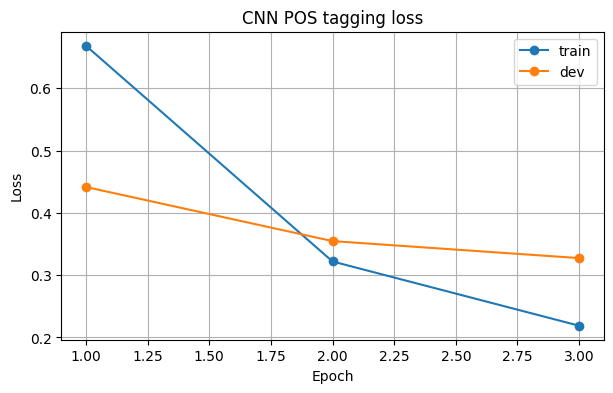

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(loss_table["epoch"], loss_table["train_loss"], marker="o", label="train")
plt.plot(loss_table["epoch"], loss_table["dev_loss"], marker="o", label="dev")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN POS tagging loss")
plt.legend()
plt.grid(True)
plt.show()


## 9. Main results

Ο τελικός πίνακας με τα αποτελέσματα:

1. **Most frequent tag baseline**,
2. **Window MLP Part 3**,
3. **BiLSTM RNN Part 4**,
4. **Stacked CNN Part 5**.



In [10]:
cnn_macro_rows = []
cnn_per_tag_rows = []

for split, loader in loaders.items():
    per_tag, macro = evaluate_sequence_model(cnn, loader)

    cnn_macro_rows.append({
        "model": "Stacked CNN Part 5",
        "split": split,
        **macro
    })

    temp = per_tag.copy()
    temp.insert(0, "split", split)
    temp.insert(0, "model", "Stacked CNN Part 5")
    cnn_per_tag_rows.append(temp)

cnn_macro = pd.DataFrame(cnn_macro_rows)
cnn_per_tag = pd.concat(cnn_per_tag_rows, ignore_index=True)

macro_results = pd.concat([
    freq_macro,
    old_window_mlp,
    old_bilstm_rnn,
    cnn_macro
], ignore_index=True)

macro_results = macro_results.sort_values(["split", "model"]).reset_index(drop=True)
display(macro_results)


,model,split,macro_precision,macro_recall,macro_f1,macro_pr_auc
0,BiLSTM RNN Part 4,dev,0.857600,0.796600,0.819000,0.857400
1,Most frequent tag,dev,0.836325,0.774837,0.791781,0.701176
2,Stacked CNN Part 5,dev,0.839413,0.809407,0.821987,0.866715
3,Window MLP Part 3,dev,0.894500,0.833600,0.848600,0.888000
4,BiLSTM RNN Part 4,test,0.856200,0.807100,0.827800,0.870900
5,Most frequent tag,test,0.819922,0.775515,0.786675,0.702739
6,Stacked CNN Part 5,test,0.852279,0.821422,0.834761,0.877031
7,Window MLP Part 3,test,0.868900,0.846300,0.856300,0.898300
8,BiLSTM RNN Part 4,train,0.934900,0.876700,0.900200,0.939600
9,Most frequent tag,train,0.896462,0.872635,0.880112,0.798483


## 10. Μικρός hyperparameter έλεγχος

Σε αυτό το section υπάρχει ένας μικρός optional έλεγχος για CNN hyperparameters.

- ποια filter sizes χρησιμοποιούνται,
- πόσα CNN blocks μπαίνουν στη σειρά,
- dropout,
- channels.

Το βασικό CNN model χρησιμοποιεί:

`filter_sizes=(2, 3, 4)` και `num_blocks=2`.

--

`RUN_SMALL_CHECK = False`

Αν γίνει `True`, τότε τρέχουν μερικές απλές δοκιμές και συγκρίνονται με το βασικό CNN.



In [11]:
RUN_SMALL_CHECK = False


def train_small_cnn_variant(setting_name, filter_sizes, num_blocks, trial_epochs=2):
    """
    Μικρή παραλλαγή για ενδεχόμενη βελτίωση.

    """
    trial = SimpleCnnPosTagger(
        vocab_size=len(word2idx),
        num_tags=len(tag_list),
        emb_dim=80,
        channels=128,
        num_blocks=num_blocks,
        filter_sizes=filter_sizes,
        dropout=0.25
    ).to(device)

    trial_opt = torch.optim.Adam(trial.parameters(), lr=0.001)

    local_best = float("inf")
    local_weights = None

    for ep in range(1, trial_epochs + 1):
        tr = pass_over_data(trial, loaders["train"], trial_opt)
        dv = pass_over_data(trial, loaders["dev"], optimizer=None)

        if dv < local_best:
            local_best = dv
            local_weights = {k: v.detach().cpu().clone() for k, v in trial.state_dict().items()}

        print(f"{setting_name} | epoch {ep}: train={tr:.4f}, dev={dv:.4f}")

    trial.load_state_dict(local_weights)
    _, dev_macro = evaluate_sequence_model(trial, loaders["dev"])
    _, test_macro = evaluate_sequence_model(trial, loaders["test"])

    return {
        "setting": setting_name,
        "best_dev_loss": local_best,
        "dev_macro_f1": dev_macro["macro_f1"],
        "test_macro_f1": test_macro["macro_f1"],
        "dev_macro_pr_auc": dev_macro["macro_pr_auc"],
        "test_macro_pr_auc": test_macro["macro_pr_auc"],
    }


main_dev_row = cnn_macro[cnn_macro["split"] == "dev"].iloc[0]
main_test_row = cnn_macro[cnn_macro["split"] == "test"].iloc[0]

# Η πρώτη γραμμή είναι πάντα το βασικό CNN model.
check_rows = [{
    "setting": "main CNN: filters 2,3,4; blocks=2",
    "best_dev_loss": best_dev,
    "dev_macro_f1": main_dev_row["macro_f1"],
    "test_macro_f1": main_test_row["macro_f1"],
    "dev_macro_pr_auc": main_dev_row["macro_pr_auc"],
    "test_macro_pr_auc": main_test_row["macro_pr_auc"],
}]

# Τρέχει μόνο αν γίνει RUN_SMALL_CHECK=True.
if RUN_SMALL_CHECK:
    check_rows.append(train_small_cnn_variant("only trigram filters; blocks=2", (3,), 2))
    check_rows.append(train_small_cnn_variant("filters 2,3,4; blocks=1", (2, 3, 4), 1))

cnn_tuning_summary = pd.DataFrame(check_rows)
display(cnn_tuning_summary)


,setting,best_dev_loss,dev_macro_f1,test_macro_f1,dev_macro_pr_auc,test_macro_pr_auc
0,"main CNN: filters 2,3,4; blocks=2",0.327355,0.821987,0.834761,0.866715,0.877031


## 11. Αποθήκευση full per tag tables για το report





In [12]:
full_per_tag_results = pd.concat([freq_per_tag, cnn_per_tag], ignore_index=True)
full_per_tag_results = full_per_tag_results.sort_values(["model", "split", "tag"]).reset_index(drop=True)

macro_results.to_csv("exercise3_cnn_macro_results.csv", index=False)
full_per_tag_results.to_csv("exercise3_cnn_per_tag_results.csv", index=False)
cnn_tuning_summary.to_csv("exercise3_cnn_tuning_summary.csv", index=False)

print("Αποθηκεύτηκαν:")
print("- exercise3_cnn_macro_results.csv")
print("- exercise3_cnn_per_tag_results.csv")
print("- exercise3_cnn_tuning_summary.csv")

display(full_per_tag_results.head(20))


Αποθηκεύτηκαν:
- exercise3_cnn_macro_results.csv
- exercise3_cnn_per_tag_results.csv
- exercise3_cnn_tuning_summary.csv


,model,split,tag,precision,recall,f1,pr_auc,support
0,Most frequent tag,dev,ADJ,0.907947,0.851475,0.878805,0.803323,1865
1,Most frequent tag,dev,ADP,0.858835,0.889598,0.873946,0.782239,2038
2,Most frequent tag,dev,ADV,0.923077,0.759740,0.833482,0.734397,1232
3,Most frequent tag,dev,AUX,0.909745,0.887683,0.898579,0.819937,1567
4,Most frequent tag,dev,CCONJ,0.987245,0.992308,0.989770,0.985626,780
5,Most frequent tag,dev,DET,0.954242,0.976842,0.965410,0.942246,1900
6,Most frequent tag,dev,INTJ,0.984848,0.565217,0.718232,0.563448,115
7,Most frequent tag,dev,NOUN,0.692666,0.917577,0.789415,0.708706,4210
8,Most frequent tag,dev,NUM,0.938356,0.715405,0.811852,0.662067,383
9,Most frequent tag,dev,PART,0.688770,0.995363,0.814159,0.724057,647


## 12. POS tags που ήταν ευκολότερα ή δυσκολότερα για το CNN


Για παράδειγμα, κάποια tags μπορεί να είναι εύκολα επειδή έχουν πολλά παραδείγματα ή ξεκάθαρα patterns. Άλλα tags μπορεί να είναι πιο δύσκολα επειδή είναι σπάνια ή μπερδεύονται με κοντινές κατηγορίες.


In [13]:
cnn_test_tags = full_per_tag_results[
    (full_per_tag_results["model"] == "Stacked CNN Part 5") &
    (full_per_tag_results["split"] == "test")
].copy()

best_tags = cnn_test_tags.sort_values("f1", ascending=False).head(8)
hard_tags = cnn_test_tags.sort_values("f1", ascending=True).head(8)

tag_summary_for_report = pd.concat([
    best_tags.assign(group="higher F1"),
    hard_tags.assign(group="lower F1")
])

display(tag_summary_for_report[["group", "tag", "precision", "recall", "f1", "pr_auc", "support"]])


,group,tag,precision,recall,f1,pr_auc,support
72,higher F1,CCONJ,0.994528,0.987772,0.991138,0.994474,736
80,higher F1,PUNCT,0.992503,0.983527,0.987995,0.998675,3096
73,higher F1,DET,0.991498,0.983658,0.987563,0.998134,1897
71,higher F1,AUX,0.976819,0.983150,0.979974,0.991873,1543
78,higher F1,PRON,0.970481,0.987523,0.978928,0.994899,2164
77,higher F1,PART,0.940565,0.975347,0.957640,0.992011,649
69,higher F1,ADP,0.937651,0.958025,0.947728,0.982287,2025
83,higher F1,VERB,0.884615,0.900576,0.892524,0.959999,2605
84,lower F1,X,0.090909,0.047619,0.062500,0.053639,42
79,lower F1,PROPN,0.719851,0.650120,0.683211,0.790391,2075


## 13. Μικρά παραδείγματα προβλέψεων

Σε αυτό το section χρησιμοποιούνται μερικές απλές προτάσεις για να δούμε πρακτικά τι προβλέπει το CNN παρόμοια παραδείγματα με το part 4.


In [14]:
def predict_tags_for_text(text):
    """
    Χρησιμοποιεί το trained CNN και προβλέπει ένα POS tag για κάθε word.
    """
    cnn.eval()

    words = text.lower().split()
    ids = [word2idx.get(word, unk_word_id) for word in words]

    x = torch.tensor([ids], dtype=torch.long).to(device)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = cnn(x, lengths)
        pred_ids = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

    return pd.DataFrame({
        "word": words,
        "predicted_tag": [idx2tag[int(i)] for i in pred_ids],
        "in_train_vocab": [w in word2idx for w in words]
    })


example_texts = [
    "Maria studies data science in Athens .",
    "The small model predicts tags for words .",
    "Alpha TV broadcast the show on Monday ."
]

for text in example_texts:
    print("\nΠρόταση:", text)
    display(predict_tags_for_text(text))



Πρόταση: Maria studies data science in Athens .


,word,predicted_tag,in_train_vocab
0,maria,ADJ,True
1,studies,NOUN,True
2,data,NOUN,True
3,science,NOUN,True
4,in,ADP,True
5,athens,NOUN,False
6,.,PUNCT,True



Πρόταση: The small model predicts tags for words .


,word,predicted_tag,in_train_vocab
0,the,DET,True
1,small,ADJ,True
2,model,NOUN,True
3,predicts,NOUN,False
4,tags,NOUN,False
5,for,ADP,True
6,words,NOUN,True
7,.,PUNCT,True



Πρόταση: Alpha TV broadcast the show on Monday .


,word,predicted_tag,in_train_vocab
0,alpha,NUM,False
1,tv,NOUN,True
2,broadcast,VERB,False
3,the,DET,True
4,show,NOUN,True
5,on,ADP,True
6,monday,PROPN,True
7,.,PUNCT,True


## 14. Ευχαριστώ

Συνολικά, το μόνο που έκανα είναι ότι κρατάω το ίδιο sequence tagging πρόβλημα και αλλάζω μόνο τον encoder από RNN σε CNN. Έπειτα συγκρίνουμε το νέο CNN με το most frequent baseline, το Part 3 Window MLP και το Part 4 BiLSTM RNN.
